ai 사용 내역 : https://claude.ai/share/9d506761-7e1a-4ed6-921a-0710cf1f0120

In [15]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \-O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

In [16]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)

N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)
texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

Q1

(a)

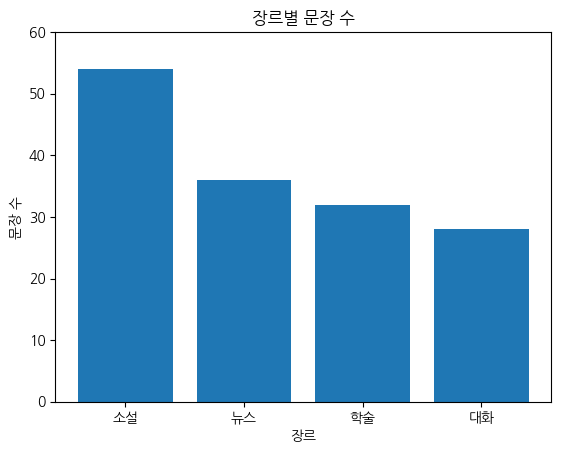

In [17]:
counts = texts['장르'].value_counts()

fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수')
ax.set_ylim(0, 60) # y축을 0부터 시작하도록 했고, 가장 긴 막대가 50을 넘기는 것을 확인한 후 상한선을 60으로 설정했다.
plt.show()

설명 : value_counts로 장르별 문장 수를 구하고, 그 결과를 막대 그래프에 옮겼다. 먼저 set_ylim 줄 없이 한 번 출력해 가장 큰 막대가 50을 조금 넘기는 것을 확인한 뒤, 그보다 여유 있게 set_ylim(0,60)으로 y축 범위를 설정했다.

(b)

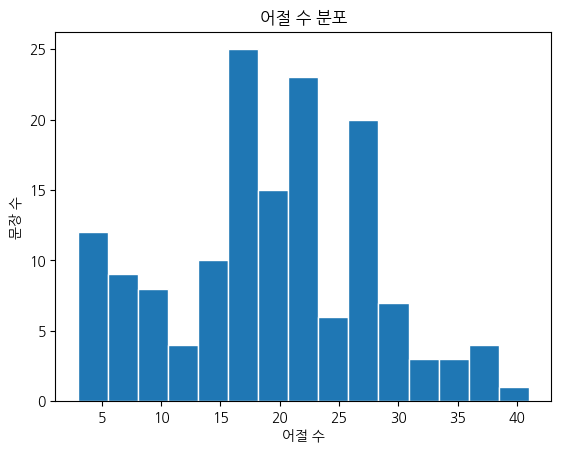

In [18]:
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white')
ax.set_title('어절 수 분포')
ax.set_xlabel('어절 수')
ax.set_ylabel('문장 수')
plt.show()

설명 : ax.hist로 어절수를 15개 구간(bin)으로 나눠 그렸으며, 막대의 높이는 그 구간에 속한 문장의 개수이므로(texts의 한 줄이 문장 하나) y축을 '문장 수'로 설정했다. 

관찰 : 어절 수는 주로 15~25 구간에 몰려 있다. (가장 높은 곳은 15보다 살짝 큰 부근, 두 번째로 높은 곳은 20보다 살짝 큰 부근)

(c)

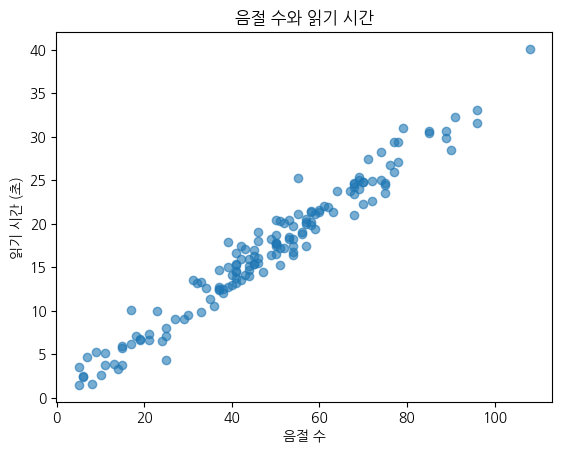

In [19]:
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.6)
ax.set_title('음절 수와 읽기 시간')
ax.set_xlabel('음절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.show()

설명 : ax.scatter로 음절 수와 읽기 시간에 대한 산점도를 그렸다. alpha는 강의 자료를 참고해 0.6으로 설정했고, 공통 데이터에서 읽기시간은 초 단위라고 명시되어 있기 때문에 y축을 읽기 시간(초)로 설정하였다.

관찰 : 두 변수는 우상향 관계를 보인다.

Q2

(a)

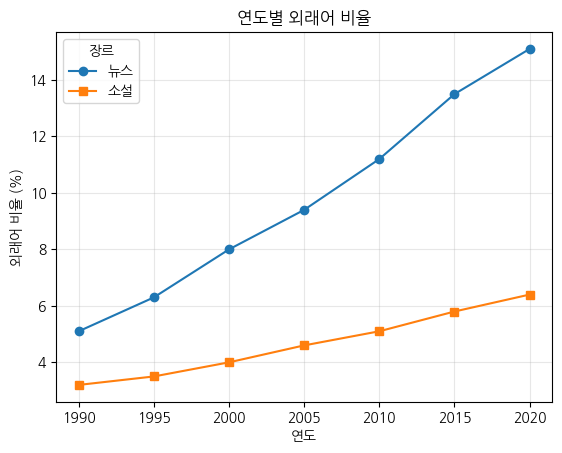

In [20]:
fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도') ; ax.set_ylabel('외래어 비율 (%)')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
plt.show()

설명 : 공통 데이터에 외래어 비율(%)이라고 단위가 명시되어 있어 y축을 외래어 비율(%)로 설정했다. marker를 각각 동그라미와 정사각형으로 주고, label로 뉴스와 소설을 지정한 뒤 ax.legend로 범례를 표시했다.

관찰 : 두 장르 모두 외래어 비율이 증가하는 추세를 보이는데, 뉴스가 훨씬 가파르게 증가하는 반면 소설은 완만하게 증가한다.

(b)

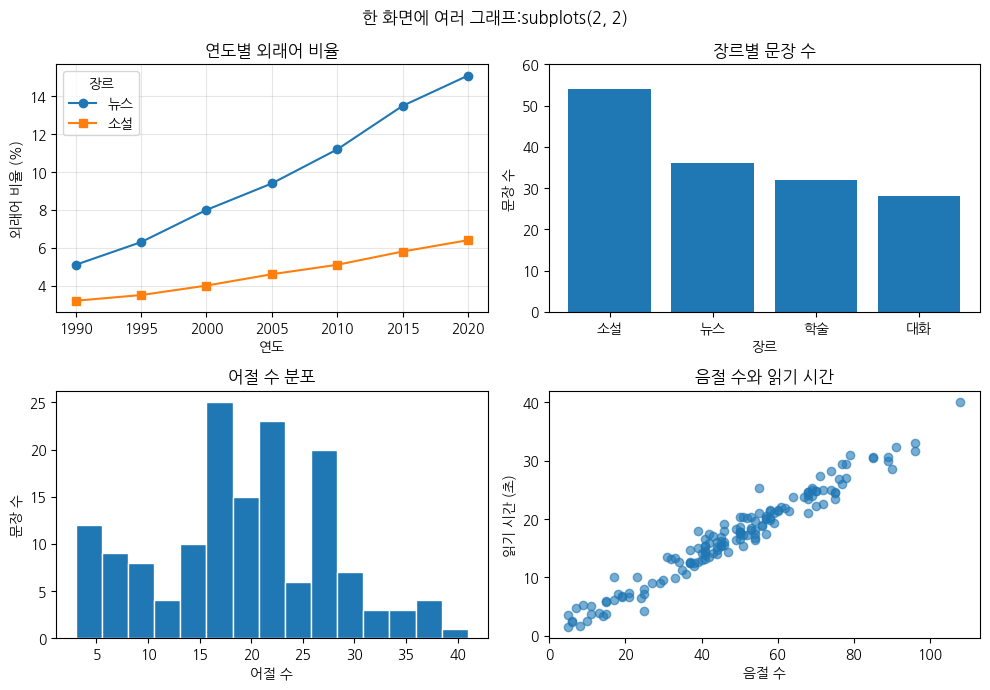

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10,7))

axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
axes[0, 0].set_title('연도별 외래어 비율')
axes[0, 0].set_xlabel('연도') ; axes[0, 0].set_ylabel('외래어 비율 (%)')
axes[0, 0].legend(title='장르')
axes[0, 0].grid(True, alpha=0.3)

counts = texts['장르'].value_counts()
axes[0, 1].bar(counts.index, counts.values)
axes[0, 1].set_title('장르별 문장 수')
axes[0, 1].set_xlabel('장르')
axes[0, 1].set_ylabel('문장 수')
axes[0, 1].set_ylim(0, 60) 

axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
axes[1, 0].set_title('어절 수 분포')
axes[1, 0].set_xlabel('어절 수')
axes[1, 0].set_ylabel('문장 수')

axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.6)
axes[1, 1].set_title('음절 수와 읽기 시간')
axes[1, 1].set_xlabel('음절 수')
axes[1, 1].set_ylabel('읽기 시간 (초)')

fig.suptitle('한 화면에 여러 그래프:subplots(2, 2)')
fig.tight_layout()
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

설명 : subplots를 이용해 한 화면(Figure)에 네 그래프를 그렸다. axes는 2차원 배열이므로 axes[행, 열]로 각 칸에 접근했다. savefig를 show 이전에 불러와 빈 파일이 저장되지 않게 했다.

Q3

(a)

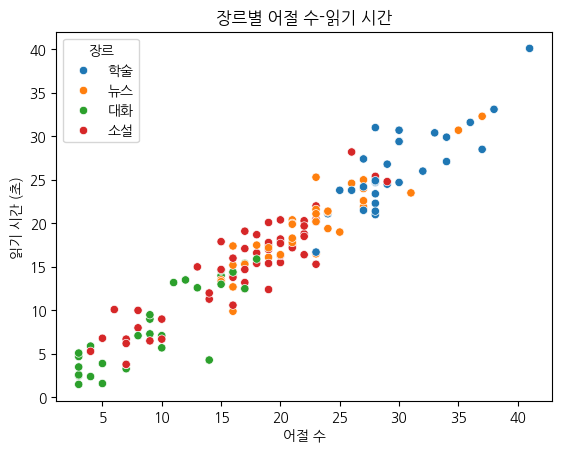

In [22]:
import seaborn as sns

fig, ax = plt.subplots()
sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', ax=ax)
ax.set_title('장르별 어절 수-읽기 시간')
ax.set_xlabel('어절 수')
ax.set_ylabel('읽기 시간 (초)') # seaborn은 자동으로 축 이름을 달아주지만, 단위를 표기하지 않아 직접 달아주었다.
plt.show()

설명 : fig, ax = plt.sublpots()로 만든 ax에 ax=ax로 연동했고, hue가 자동으로 색을 나누고 범례까지 설정해줬다. seaborn은 자동으로 축 이름을 설정해 주기 때문에 강의에선 축 이름을 설정해 주지 않았지만, 그럴시에 읽기 시간의 단위인 (초)가 나오지 않고, 문제 조건에 모든 그래프에 제목과 축 이름을 달라고 명시되어 있으므로 직접 xlabel과 ylabel을 설정했다.

(b)

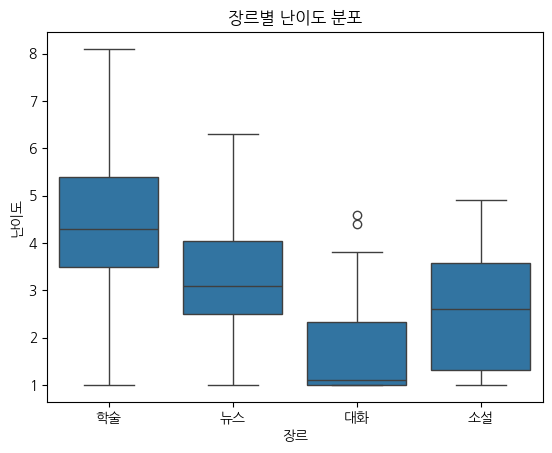

In [23]:
fig, ax = plt.subplots()
sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)
ax.set_title('장르별 난이도 분포')
ax.set_xlabel('장르')
ax.set_ylabel('난이도')
plt.show()

설명 : x=장르, y=난이도인 상자그림을 그렸다. 이는 다이너마이트 plot이 숨긴 퍼짐과 이상치까지 보여준다. 이 또한 문제 조건에 맞게 직접 xlabel과 ylabel을 설정해 주었다.

관찰 : 가장 난이도가 높은 장르는 학술이며, 퍼짐(상자의 크기)이 가장 큰 장르는 소설이다.

(c)

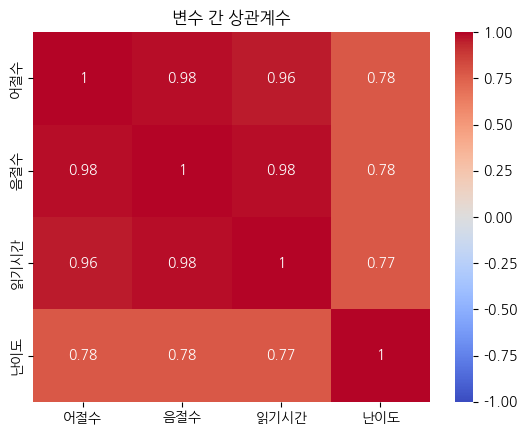

In [24]:
corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('변수 간 상관계수')
plt.show()

설명 : 네 변수 간 상관계수를 구하고 색으로 표현한 히트맵을 그렸다. annot=True로 두어 상관계수 숫자도 함께 표시하도록 했고, cmap='coolwarm'으로 색 지도도 포함시켰다.

관찰 : 서로 가장 강하게 함께 증가하는 두 변수는 상관계수가 +0.98로 가장 +1에 가까운 어절수-음절수, 그리고 음절수-읽기시간이다. 이는 어절이 여러 음절로 이루어져 있기 때문에 어절이 증가하면 음절도 함께 증가하고, 또한 음절이 많을수록 읽는 데 더 오랜 시간이 걸리기 때문인 것으로 보인다.

Q4

(a)

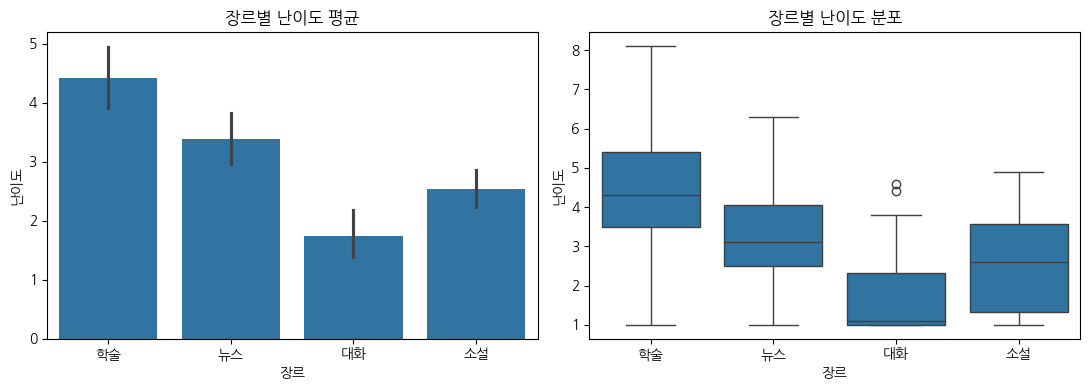

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 난이도 평균')
axes[0].set_xlabel('장르') ; axes[0].set_ylabel('난이도')

sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
axes[1].set_title('장르별 난이도 분포')
axes[1].set_xlabel('장르') ; axes[1].set_ylabel('난이도')

fig.tight_layout()
plt.show()

설명 : subplots(1, 2)로 같은 난이도 데이터를 왼쪽 axes[0]에선 장르별 평균(+신뢰구간)을 나타내는 막대 그래프로, 오른쪽 axes[1]에선 장르별 분포를 나타내는 상자 그림으로 그렸다. 막대 그래프는 평균과 신뢰구간만 나타내고, 상자 그림은 중앙값, 전체 범위, 이상치까지 보여준다.

서술 : 왼쪽 막대 그래프("다이너마이트 플롯")은 평균과 신뢰구간만 보여주고 퍼짐, 이상치와 같은 분포는 숨긴다. 예를 들어 두 장르의 평균 난이도가 똑같으면 막대는 같은 높이로 그려지지만, 한 장르는 값이 평균 부근에 좁게 모여 있고 다른 장르는 쉬운 문장부터 어려운 문장까지 넓게 흩어져 있어 분포가 전혀 다를 수 있는데, 이런 차이는 상자그림에서만 볼 수 있다. 실제로 오른쪽 상자그림에선 수염을 통해 난이도가 얼마나 넓게 퍼져 있는지를 알 수 있고, 막대 그래프에는 나타나지 않았던 이상치도 대화 장르에서 나타난다. 

(b)

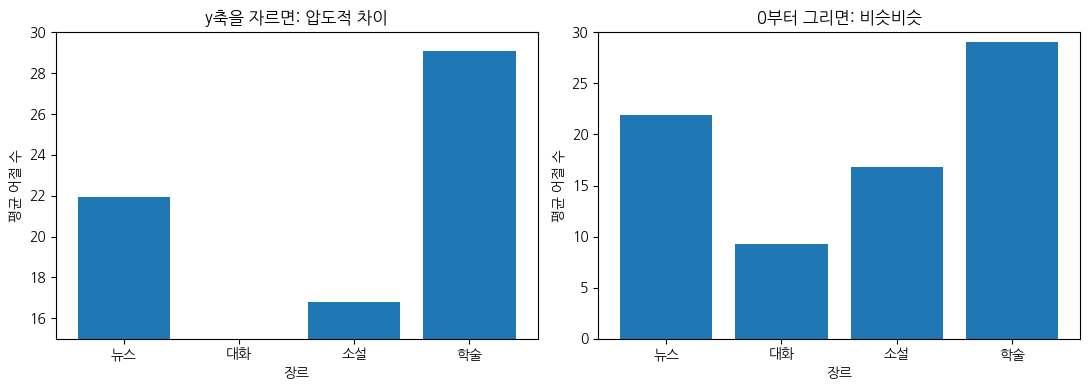

In [26]:
mean = texts.groupby('장르')['어절수'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(mean.index, mean.values)
axes[0].set_title('y축을 자르면: 압도적 차이')
axes[0].set_xlabel('장르') ; axes[0].set_ylabel('평균 어절 수')
axes[0].set_ylim(15, 30)

axes[1].bar(mean.index, mean.values)
axes[1].set_title('0부터 그리면: 비슷비슷')
axes[1].set_xlabel('장르') ; axes[1].set_ylabel('평균 어절 수')
axes[1].set_ylim(0, 30)

fig.tight_layout()
plt.show()

설명 : groupby로 구한 같은 평균값을 mean으로 두고 두 막대 그래프에 똑같이 그리되, 왼쪽은 set_ylim(15, 30)으로 y축을 잘라내고 오른쪽은 set_ylim(0, 30)으로 0부터 그렸다. 

서술 : 같은 숫자인데도 왼쪽 그래프는 네 장르 간 차이가 압도적으로 큰 인상을 주고, 대화는 평균이 15보다 작아 완전히 사라지기까지 했다. 오른쪽 그래프에서는 네 장르의 평균이 실제로는 왼쪽만큼 크지 않다는 것이 드러난다. 막대 그래프는 길이가 평균의 크기를 나타내기 때문에 길이가 중요하고, 따라서 막대 그래프의 y축을 0부터 시작해 길이 차이를 제대로 표현해야 한다.